# Kalman Filter Assessment for Rootzone pH and EC

This notebook converts the standalone benchmark into a notebook workflow and answers the practical question directly: can a Kalman filter predict root-zone `pH` and `EC` well enough to challenge the latest committed `v7` models?

## Short answer

- For `pH`, a Kalman model **is viable as a baseline** because the series has a visible diurnal component. The best tested Kalman variant reached **MAE 0.451** and **R² 0.863**, which is much better than naive carry-forward (**MAE 0.827**) but still behind `v7_24h` (**MAE 0.332**, **R² 0.928**).
- For `EC`, the tested Kalman variants are **not strong enough as standalone predictors**. The CV-selected Kalman model landed at **MAE 0.331** and **R² 0.640**, while `v7_24h` stayed clearly better at **MAE 0.179** and **R² 0.821**. Even the exploratory best-holdout Kalman run (**MAE 0.251**) did not catch up.

The rest of the notebook shows why that happens and leaves the exported CSVs in `scripts/exports/`.


In [1]:
from pathlib import Path
import html
import pandas as pd
import numpy as np
from IPython.display import HTML, SVG, display

ROOT = Path.cwd().resolve()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
MASTER_PATH = ROOT / "data" / "processed" / "master.csv"
EXPORT_DIR = ROOT / "scripts" / "exports"


def display_df(df, rows=None):
    show_df = df.head(rows) if rows is not None else df
    display(HTML(show_df.to_html(index=False, float_format=lambda x: f"{x:.3f}" if isinstance(x, (int, float, np.floating)) else str(x))))


def _palette(label):
    if label.startswith("v7"):
        return "#1f77b4"
    if label.startswith("kalman_selected"):
        return "#ff7f0e"
    if label.startswith("kalman_best_holdout"):
        return "#9467bd"
    return "#7f7f7f"


def svg_metric_bar(frame, metric, title, lower_is_better=True, width=920, height=360):
    data = frame.copy().reset_index(drop=True)
    margin_left, margin_right, margin_top, margin_bottom = 70, 24, 54, 72
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom
    max_val = float(max(data[metric].max() * 1.15, 1e-6))
    bar_w = plot_w / max(len(data), 1)
    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">']
    lines.append(f'<rect width="{width}" height="{height}" fill="white"/>')
    lines.append(f'<text x="{width/2}" y="28" text-anchor="middle" font-size="20" font-family="Arial" fill="#111">{html.escape(title)}</text>')
    lines.append(f'<text x="{width/2}" y="48" text-anchor="middle" font-size="12" font-family="Arial" fill="#555">{"Lower is better" if lower_is_better else "Higher is better"}</text>')
    lines.append(f'<line x1="{margin_left}" y1="{height-margin_bottom}" x2="{width-margin_right}" y2="{height-margin_bottom}" stroke="#444"/>')
    lines.append(f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{height-margin_bottom}" stroke="#444"/>')
    for i in range(5):
        value = max_val * i / 4.0
        y = height - margin_bottom - plot_h * i / 4.0
        lines.append(f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width-margin_right}" y2="{y:.1f}" stroke="#e6e6e6"/>')
        lines.append(f'<text x="{margin_left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11" font-family="Arial" fill="#555">{value:.2f}</text>')
    for idx, row in data.iterrows():
        value = float(row[metric])
        x = margin_left + idx * bar_w + bar_w * 0.16
        y = height - margin_bottom - (value / max_val) * plot_h
        h = height - margin_bottom - y
        color = _palette(str(row["model"]))
        lines.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_w*0.68:.1f}" height="{h:.1f}" rx="4" fill="{color}" opacity="0.9"/>')
        lines.append(f'<text x="{x + bar_w*0.34:.1f}" y="{y-6:.1f}" text-anchor="middle" font-size="11" font-family="Arial" fill="#222">{value:.3f}</text>')
        label = str(row["model"]).replace("kalman_selected_", "kalman cv: ").replace("kalman_best_holdout_", "kalman best: ")
        lines.append(f'<text transform="translate({x + bar_w*0.34:.1f},{height-margin_bottom+16}) rotate(28)" font-size="11" font-family="Arial" fill="#222">{html.escape(label)}</text>')
    lines.append("</svg>")
    return "".join(lines)


def svg_gap_timeline(gaps, title, width=920, height=320):
    gaps = np.asarray(gaps, dtype=float)
    margin_left, margin_right, margin_top, margin_bottom = 70, 20, 40, 48
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom
    max_gap = max(float(gaps.max()), 1.0)
    y_max = np.log10(1.0 + max_gap)

    def x_pos(i):
        return margin_left + plot_w * i / max(len(gaps) - 1, 1)

    def y_pos(v):
        return margin_top + plot_h * (1.0 - np.log10(1.0 + max(v, 0.0)) / y_max)

    points = " ".join(f"{x_pos(i):.1f},{y_pos(v):.1f}" for i, v in enumerate(gaps))
    med = float(np.median(gaps))
    p90 = float(np.quantile(gaps, 0.9))
    ticks = [0.5, 2, 6, 24, 72, 168, max_gap]
    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">']
    lines.append(f'<rect width="{width}" height="{height}" fill="white"/>')
    lines.append(f'<text x="{width/2}" y="24" text-anchor="middle" font-size="20" font-family="Arial" fill="#111">{html.escape(title)}</text>')
    lines.append(f'<text x="{width/2}" y="42" text-anchor="middle" font-size="12" font-family="Arial" fill="#555">Y axis uses log10(1 + gap_hours) so rare very long gaps stay visible.</text>')
    lines.append(f'<line x1="{margin_left}" y1="{height-margin_bottom}" x2="{width-margin_right}" y2="{height-margin_bottom}" stroke="#444"/>')
    lines.append(f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{height-margin_bottom}" stroke="#444"/>')
    for tick in ticks:
        y = y_pos(tick)
        lines.append(f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width-margin_right}" y2="{y:.1f}" stroke="#ececec"/>')
        lines.append(f'<text x="{margin_left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11" font-family="Arial" fill="#555">{tick:.1f}</text>')
    lines.append(f'<polyline fill="none" stroke="#1f77b4" stroke-width="2" points="{points}"/>')
    for ref, label, color in [(med, "median", "#ff7f0e"), (p90, "p90", "#d62728")]:
        y = y_pos(ref)
        lines.append(f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width-margin_right}" y2="{y:.1f}" stroke="{color}" stroke-dasharray="6,4"/>')
        lines.append(f'<text x="{width-margin_right}" y="{y-6:.1f}" text-anchor="end" font-size="11" font-family="Arial" fill="{color}">{label}: {ref:.1f} h</text>')
    lines.append("</svg>")
    return "".join(lines)


def svg_error_timeline(frame, title, kalman_col="kalman_abs_err", v7_col="v7_abs_err", width=920, height=320):
    data = frame.copy().reset_index(drop=True)
    margin_left, margin_right, margin_top, margin_bottom = 70, 20, 44, 52
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom
    max_err = max(float(data[[kalman_col, v7_col]].to_numpy().max()) * 1.1, 1e-6)

    def x_pos(i):
        return margin_left + plot_w * i / max(len(data) - 1, 1)

    def y_pos(v):
        return margin_top + plot_h * (1.0 - v / max_err)

    kalman_points = " ".join(f"{x_pos(i):.1f},{y_pos(v):.1f}" for i, v in enumerate(data[kalman_col]))
    v7_points = " ".join(f"{x_pos(i):.1f},{y_pos(v):.1f}" for i, v in enumerate(data[v7_col]))
    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">']
    lines.append(f'<rect width="{width}" height="{height}" fill="white"/>')
    lines.append(f'<text x="{width/2}" y="24" text-anchor="middle" font-size="20" font-family="Arial" fill="#111">{html.escape(title)}</text>')
    lines.append(f'<line x1="{margin_left}" y1="{height-margin_bottom}" x2="{width-margin_right}" y2="{height-margin_bottom}" stroke="#444"/>')
    lines.append(f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{height-margin_bottom}" stroke="#444"/>')
    for i in range(5):
        value = max_err * i / 4.0
        y = height - margin_bottom - plot_h * i / 4.0
        lines.append(f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width-margin_right}" y2="{y:.1f}" stroke="#ececec"/>')
        lines.append(f'<text x="{margin_left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11" font-family="Arial" fill="#555">{value:.2f}</text>')
    lines.append(f'<polyline fill="none" stroke="#ff7f0e" stroke-width="2" points="{kalman_points}"/>')
    lines.append(f'<polyline fill="none" stroke="#1f77b4" stroke-width="2" points="{v7_points}"/>')
    lines.append(f'<rect x="{margin_left}" y="{height-30}" width="14" height="14" fill="#ff7f0e"/>')
    lines.append(f'<text x="{margin_left+20}" y="{height-18}" font-size="12" font-family="Arial" fill="#222">Kalman absolute error</text>')
    lines.append(f'<rect x="{margin_left+210}" y="{height-30}" width="14" height="14" fill="#1f77b4"/>')
    lines.append(f'<text x="{margin_left+230}" y="{height-18}" font-size="12" font-family="Arial" fill="#222">V7 absolute error</text>')
    lines.append("</svg>")
    return "".join(lines)


## Benchmark Implementation

The next cell contains the same benchmark logic that was previously in the `.py` script. It builds label-to-label intervals, tests several Kalman-style candidates, selects models using only pre-holdout CV, and writes comparison artifacts into `scripts/exports`.


In [2]:
ACID_FERTS = ["Phosphoric acid[mg]-H3PO4"]
SALT_FERTS = [
    "Monopotassium Phosphate[mg] -KH2PO4",
    "Potassium Chloride[mg] - KCL",
    "Kortin [mg]",
    "Ammonium Nitrate [mg] -NH4NO3",
    "Gypsum - CaSO4*2H2O [mg]",
]

DELTA_FEATURES = {
    "ph": [
        "ph0",
        "ec0",
        "gap_hours",
        "photo_temp_interaction",
        "overnight_h",
        "ET0_per_hour",
        "hist_irr_mid",
        "transpiration_pull",
        "soil_delta",
        "hist_acid_decay",
        "hist_hrs_since_fert",
        "hist48_irr_prevday",
        "rad_morning",
        "t0_morning",
        "t1_morning",
        "hist_irr_prior",
        "hist_hrs_since_irr",
    ],
    "ec": [
        "ec0",
        "gap_hours",
        "log_ec_drive",
        "hist_acid_decay",
        "hist_hrs_since_fert",
        "hist_irr_recent",
        "hist_hrs_since_irr",
        "temp_trend",
        "hist_salt_buildup",
        "hist_irr_prior",
        "hist_irr_mid",
        "soil_temp_mean",
    ],
}

LOG_FEATURES = {
    "gap_hours",
    "hist_acid_decay",
    "hist_hrs_since_fert",
    "hist_irr_recent",
    "hist_hrs_since_irr",
    "hist_salt_buildup",
    "hist_irr_prior",
    "hist_irr_mid",
    "hist48_irr_prevday",
    "weighted_irr",
    "weighted_total_fert",
    "weighted_fert_acid",
    "weighted_fert_salt",
    "rad_morning",
}


def mae(y: pd.Series | np.ndarray, pred: pd.Series | np.ndarray) -> float:
    y_arr = np.asarray(y, dtype=float)
    p_arr = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs(y_arr - p_arr)))


def rmse(y: pd.Series | np.ndarray, pred: pd.Series | np.ndarray) -> float:
    y_arr = np.asarray(y, dtype=float)
    p_arr = np.asarray(pred, dtype=float)
    return float(np.sqrt(np.mean((y_arr - p_arr) ** 2)))


def r2(y: pd.Series | np.ndarray, pred: pd.Series | np.ndarray) -> float:
    y_arr = np.asarray(y, dtype=float)
    p_arr = np.asarray(pred, dtype=float)
    ss_tot = float(np.sum((y_arr - y_arr.mean()) ** 2))
    if ss_tot <= 0.0:
        return float("nan")
    ss_res = float(np.sum((y_arr - p_arr) ** 2))
    return float(1.0 - ss_res / ss_tot)


def metrics_from_eval(eval_df: pd.DataFrame) -> dict[str, float]:
    return {
        "rows": int(len(eval_df)),
        "mae": mae(eval_df["true"], eval_df["pred"]),
        "rmse": rmse(eval_df["true"], eval_df["pred"]),
        "r2": r2(eval_df["true"], eval_df["pred"]),
        "naive_mae": mae(eval_df["true"], eval_df["naive"]),
        "naive_rmse": rmse(eval_df["true"], eval_df["naive"]),
        "naive_r2": r2(eval_df["true"], eval_df["naive"]),
    }


def _to_num(series: pd.Series, default: float = 0.0) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(default)


def _sum_avail(frame: pd.DataFrame, cols: list[str]) -> float:
    use_cols = [col for col in cols if col in frame.columns]
    if not use_cols:
        return 0.0
    return float(
        frame[use_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).sum().sum()
    )


def _sum_avail_series(frame: pd.DataFrame, cols: list[str]) -> pd.Series:
    use_cols = [col for col in cols if col in frame.columns]
    if not use_cols:
        return pd.Series(0.0, index=frame.index)
    return frame[use_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).sum(axis=1)


def _get_fert_any(frame: pd.DataFrame) -> pd.Series:
    if "fertilization_flag" in frame.columns:
        return _to_num(frame["fertilization_flag"])

    has_a = "fertilization_type_a_flag" in frame.columns
    has_b = "fertilization_type_b_flag" in frame.columns
    if not has_a and not has_b:
        return pd.Series(0.0, index=frame.index)

    fert_a = (
        _to_num(frame["fertilization_type_a_flag"])
        if has_a
        else pd.Series(0.0, index=frame.index)
    )
    fert_b = (
        _to_num(frame["fertilization_type_b_flag"])
        if has_b
        else pd.Series(0.0, index=frame.index)
    )
    return ((fert_a > 0.0) | (fert_b > 0.0)).astype(float)


def load_master() -> pd.DataFrame:
    master_df = pd.read_csv(MASTER_PATH, parse_dates=["timestamp"])
    master_df = master_df.sort_values("timestamp").set_index("timestamp")
    for col in master_df.columns:
        master_df[col] = pd.to_numeric(master_df[col], errors="coerce")
    master_df["soil_temp_pred"] = master_df["soil_temp_pred"].interpolate(
        limit_direction="both"
    )
    return master_df


def get_window_features(master_df: pd.DataFrame, t0: pd.Timestamp, t1: pd.Timestamp) -> dict:
    ph0 = float(master_df.loc[t0, "ph"])
    ec0 = float(master_df.loc[t0, "ec_ms"])
    gap_h = float((t1 - t0).total_seconds() / 3600.0)
    safe_gap_h = max(gap_h, 0.16)

    seg = master_df.loc[(master_df.index >= t0) & (master_df.index < t1)]

    fert_acid_total = _sum_avail(seg, ACID_FERTS)
    fert_salt_total = _sum_avail(seg, SALT_FERTS)
    fert_total = fert_acid_total + fert_salt_total
    irr_total = float(_to_num(seg["irrigation_ml_current"]).sum()) if len(seg) else 0.0

    fert_acid_series = _sum_avail_series(seg, ACID_FERTS)
    fert_salt_series = _sum_avail_series(seg, SALT_FERTS)
    fert_total_series = fert_acid_series + fert_salt_series
    irr_series = (
        _to_num(seg["irrigation_ml_current"])
        if "irrigation_ml_current" in seg.columns
        else pd.Series(0.0, index=seg.index)
    )

    time_to_t1_h = (t1 - seg.index).total_seconds() / 3600.0 if len(seg) else np.array([])
    decay_lambda = 0.34
    weights = np.exp(-decay_lambda * time_to_t1_h) if len(seg) else np.array([])

    weighted_irr = float((irr_series * weights).sum()) if len(seg) else 0.0
    weighted_fert_acid = float((fert_acid_series * weights).sum()) if len(seg) else 0.0
    weighted_fert_salt = float((fert_salt_series * weights).sum()) if len(seg) else 0.0
    weighted_total_fert = float((fert_total_series * weights).sum()) if len(seg) else 0.0

    fert_conc = float(fert_total / (irr_total + 1.0))
    log_ec_drive = float(np.log(fert_conc + 0.01) - np.log(ec0 + 0.01))
    salt_balance = float(fert_salt_total - irr_total)

    et0_sum = float(_to_num(seg["ET0"]).sum()) if "ET0" in seg.columns and len(seg) else 0.0
    et0_per_hour = float(et0_sum / safe_gap_h)

    if (
        "internal_air_temp_c" in seg.columns
        and "internal_rh_%" in seg.columns
        and len(seg) > 0
    ):
        temps = _to_num(seg["internal_air_temp_c"])
        rhs = _to_num(seg["internal_rh_%"])
        ess = 0.6108 * np.exp((17.27 * temps) / (temps + 237.3))
        vpds = ess * (1.0 - rhs / 100.0)
        vpd_mean = float(vpds.mean())
    else:
        vpd_mean = 0.0

    soil_temp_mean = (
        float(_to_num(seg["soil_temp_pred"]).mean()) if "soil_temp_pred" in seg.columns and len(seg) else 0.0
    )
    canopy = float(_to_num(seg["canopy_cover"]).mean()) if "canopy_cover" in seg.columns and len(seg) else 0.0
    transpiration_pull = float(vpd_mean * canopy)
    photo_temp_interaction = float(vpd_mean * soil_temp_mean)

    temp_series = (
        _to_num(seg["internal_air_temp_c"])
        if "internal_air_temp_c" in seg.columns
        else pd.Series(dtype=float)
    )
    temp_trend = float(temp_series.iloc[-1] - temp_series.iloc[0]) if len(temp_series) > 1 else 0.0

    if "irrigation_ml_current" in seg.columns and len(seg) > 0:
        irr_events = _to_num(seg["irrigation_ml_current"])
        irr_times = irr_events[irr_events > 0.0].index
        hrs_since_irr = (
            float((t1 - irr_times.max()).total_seconds() / 3600.0)
            if len(irr_times) > 0
            else gap_h
        )
    else:
        hrs_since_irr = gap_h

    fert_series = _get_fert_any(seg) if len(seg) > 0 else pd.Series(dtype=float)
    fert_times = fert_series[fert_series > 0.0].index
    hrs_since_fert = (
        float((t1 - fert_times.max()).total_seconds() / 3600.0)
        if len(fert_times) > 0
        else gap_h
    )

    t0_morning = int(5 <= t0.hour <= 10)
    t1_morning = int(5 <= t1.hour <= 10)
    soil_t1 = float(master_df.loc[t1, "soil_temp_pred"])
    soil_t0 = float(master_df.loc[t0, "soil_temp_pred"])
    soil_delta = float(soil_t1 - soil_t0)
    overnight_h = (
        float((_to_num(seg["internal_radiation"]) <= 10.0).sum()) / 6.0 if len(seg) else 0.0
    )
    rad_morning = (
        float(
            _to_num(seg.loc[(seg.index.hour >= 6) & (seg.index.hour < 12), "internal_radiation"]).sum()
        )
        if len(seg)
        else 0.0
    )

    return {
        "ph0": ph0,
        "ec0": ec0,
        "gap_hours": gap_h,
        "weighted_irr": weighted_irr,
        "weighted_total_fert": weighted_total_fert,
        "weighted_fert_acid": weighted_fert_acid,
        "weighted_fert_salt": weighted_fert_salt,
        "salt_balance_t0_t1": salt_balance,
        "log_ec_drive": log_ec_drive,
        "ET0_per_hour": et0_per_hour,
        "photo_temp_interaction": photo_temp_interaction,
        "transpiration_pull": transpiration_pull,
        "soil_temp_mean": soil_temp_mean,
        "temp_trend": temp_trend,
        "hrs_since_irr": hrs_since_irr,
        "hrs_since_fert": hrs_since_fert,
        "t0_morning": t0_morning,
        "t1_morning": t1_morning,
        "soil_delta": soil_delta,
        "overnight_h": overnight_h,
        "rad_morning": rad_morning,
    }


def get_history_features(master_df: pd.DataFrame, t1: pd.Timestamp) -> dict:
    def seg_range(start: pd.Timestamp, stop: pd.Timestamp) -> pd.DataFrame:
        if start >= stop:
            return master_df.iloc[0:0]
        return master_df.loc[(master_df.index >= start) & (master_df.index < stop)]

    irr_recent_seg = seg_range(t1 - pd.Timedelta(hours=6), t1)
    irr_mid_seg = seg_range(t1 - pd.Timedelta(hours=12), t1 - pd.Timedelta(hours=6))
    irr_prior_seg = seg_range(t1 - pd.Timedelta(hours=24), t1 - pd.Timedelta(hours=12))

    def irr_sum(seg: pd.DataFrame) -> float:
        if "irrigation_ml_current" not in seg.columns or len(seg) == 0:
            return 0.0
        return float(_to_num(seg["irrigation_ml_current"]).sum())

    hist_irr_recent = irr_sum(irr_recent_seg)
    hist_irr_mid = irr_sum(irr_mid_seg)
    hist_irr_prior = irr_sum(irr_prior_seg)

    acid_window = seg_range(t1 - pd.Timedelta(hours=24), t1)
    if len(acid_window) > 0:
        acid_doses = _sum_avail_series(acid_window, ACID_FERTS)
        nonzero = acid_doses > 0.0
        if nonzero.any():
            hrs_before = np.array((t1 - acid_window.index[nonzero]).total_seconds()) / 3600.0
            hist_acid_decay = float(
                (acid_doses[nonzero].values * np.exp(-0.34 * hrs_before)).sum()
            )
        else:
            hist_acid_decay = 0.0
    else:
        hist_acid_decay = 0.0

    state_window = seg_range(t1 - pd.Timedelta(hours=24), t1)
    if len(state_window) > 1:
        irr_state = _to_num(state_window["irrigation_ml_current"])
        h_salt = _sum_avail(state_window, SALT_FERTS)
        hist_salt_buildup = float(h_salt - float(irr_state.sum()) * 0.1)

        fert_state = _get_fert_any(state_window)
        fert_times = state_window.index[fert_state > 0.0]
        hist_hrs_since_fert = (
            float((t1 - fert_times[-1]).total_seconds() / 3600.0) if len(fert_times) > 0 else 24.0
        )

        irr_times = state_window.index[irr_state > 0.0]
        hist_hrs_since_irr = (
            float((t1 - irr_times[-1]).total_seconds() / 3600.0) if len(irr_times) > 0 else 24.0
        )
    else:
        hist_salt_buildup = 0.0
        hist_hrs_since_fert = 24.0
        hist_hrs_since_irr = 24.0

    return {
        "hist_irr_recent": hist_irr_recent,
        "hist_irr_mid": hist_irr_mid,
        "hist_irr_prior": hist_irr_prior,
        "hist_acid_decay": hist_acid_decay,
        "hist_salt_buildup": hist_salt_buildup,
        "hist_hrs_since_fert": hist_hrs_since_fert,
        "hist_hrs_since_irr": hist_hrs_since_irr,
    }


def get_prevday_features(master_df: pd.DataFrame, t1: pd.Timestamp) -> dict:
    start = t1 - pd.Timedelta(hours=48)
    stop = t1 - pd.Timedelta(hours=24)
    seg = master_df.loc[(master_df.index >= start) & (master_df.index < stop)]
    hist48_irr_prevday = (
        float(_to_num(seg["irrigation_ml_current"]).sum())
        if "irrigation_ml_current" in seg.columns and len(seg) > 0
        else 0.0
    )
    return {"hist48_irr_prevday": hist48_irr_prevday}


def build_labels_and_intervals(master_df: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    labels = (
        master_df.loc[master_df[target_col].notna(), [target_col]]
        .reset_index()
        .rename(columns={target_col: "value"})
    )

    rows: list[dict] = []
    for label_idx in range(1, len(labels)):
        t0 = pd.Timestamp(labels.loc[label_idx - 1, "timestamp"])
        t1 = pd.Timestamp(labels.loc[label_idx, "timestamp"])
        feature_row = get_window_features(master_df, t0, t1)
        feature_row.update(get_history_features(master_df, t1))
        feature_row.update(get_prevday_features(master_df, t1))
        feature_row.update(
            {
                "label_idx": int(label_idx),
                "timestamp": t1,
                "prev_timestamp": t0,
                "prev_value": float(labels.loc[label_idx - 1, "value"]),
                "value": float(labels.loc[label_idx, "value"]),
                "delta": float(labels.loc[label_idx, "value"] - labels.loc[label_idx - 1, "value"]),
            }
        )
        rows.append(feature_row)

    intervals = pd.DataFrame(rows)
    return labels, intervals


def fit_ridge(X: np.ndarray, y: np.ndarray, alpha: float) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma < 1e-8] = 1.0
    Xs = (X - mu) / sigma
    Xa = np.column_stack([np.ones(len(Xs)), Xs])
    reg = np.eye(Xa.shape[1]) * alpha
    reg[0, 0] = 0.0
    beta = np.linalg.solve(Xa.T @ Xa + reg, Xa.T @ y)
    pred = Xa @ beta
    resid = y - pred
    return beta, mu, sigma, resid


def transform_features(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for col in feature_cols:
        values = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
        if col in LOG_FEATURES:
            out[col] = np.log1p(np.clip(values, 0.0, None))
        else:
            out[col] = values
    return out


def run_local_trend(
    labels: pd.DataFrame, start_eval_idx: int, end_eval_idx: int, q_scale: float, r_scale: float
) -> pd.DataFrame:
    diff_var = max(float(np.var(labels["value"].diff().dropna().values)), 1e-6)
    q = diff_var * q_scale
    r = diff_var * r_scale

    x = np.array([float(labels.loc[0, "value"]), 0.0], dtype=float)
    P = np.eye(2)
    H = np.array([1.0, 0.0], dtype=float)
    I = np.eye(2)
    prev_time = pd.Timestamp(labels.loc[0, "timestamp"])
    rows: list[dict] = []

    for label_idx in range(1, end_eval_idx + 1):
        timestamp = pd.Timestamp(labels.loc[label_idx, "timestamp"])
        dt = float((timestamp - prev_time).total_seconds() / 3600.0)
        A = np.array([[1.0, dt], [0.0, 1.0]], dtype=float)
        Q = q * np.array(
            [[dt**3 / 3.0, dt**2 / 2.0], [dt**2 / 2.0, max(dt, 1e-6)]],
            dtype=float,
        )
        x_prior = A @ x
        P_prior = A @ P @ A.T + Q
        y_true = float(labels.loc[label_idx, "value"])

        if label_idx == start_eval_idx:
            rows.append(
                {
                    "timestamp": timestamp,
                    "true": y_true,
                    "pred": y_true,
                    "naive": y_true,
                    "gap_hours": 0.0,
                }
            )
        elif label_idx > start_eval_idx:
            rows.append(
                {
                    "timestamp": timestamp,
                    "true": y_true,
                    "pred": float(H @ x_prior),
                    "naive": float(labels.loc[label_idx - 1, "value"]),
                    "gap_hours": dt,
                }
            )

        innovation = y_true - float(H @ x_prior)
        S = float(H @ P_prior @ H.T + r)
        K = (P_prior @ H[:, None]) / S
        x = x_prior + K[:, 0] * innovation
        P = (I - K @ H[None, :]) @ P_prior
        prev_time = timestamp

    return pd.DataFrame(rows)


def run_seasonal24h(
    labels: pd.DataFrame,
    start_eval_idx: int,
    end_eval_idx: int,
    q_level_scale: float,
    q_season_scale: float,
    r_scale: float,
) -> pd.DataFrame:
    diff_var = max(float(np.var(labels["value"].diff().dropna().values)), 1e-6)
    q_level = diff_var * q_level_scale
    q_season = diff_var * q_season_scale
    r = diff_var * r_scale

    def obs_vec(ts: pd.Timestamp) -> np.ndarray:
        hour = ts.hour + ts.minute / 60.0
        angle = 2.0 * np.pi * hour / 24.0
        return np.array([1.0, np.sin(angle), np.cos(angle)], dtype=float)

    x = np.array([float(labels.loc[0, "value"]), 0.0, 0.0], dtype=float)
    P = np.eye(3)
    rows: list[dict] = []

    for label_idx in range(0, end_eval_idx + 1):
        timestamp = pd.Timestamp(labels.loc[label_idx, "timestamp"])
        H = obs_vec(timestamp)

        if label_idx == 0:
            x_prior = x.copy()
            P_prior = P.copy()
            dt = 0.0
        else:
            prev_time = pd.Timestamp(labels.loc[label_idx - 1, "timestamp"])
            dt = float((timestamp - prev_time).total_seconds() / 3600.0)
            Q = np.diag(
                [
                    q_level * max(dt, 1e-4),
                    q_season * max(dt / 24.0, 1e-4),
                    q_season * max(dt / 24.0, 1e-4),
                ]
            )
            x_prior = x.copy()
            P_prior = P + Q

        y_true = float(labels.loc[label_idx, "value"])
        if label_idx == start_eval_idx:
            rows.append(
                {
                    "timestamp": timestamp,
                    "true": y_true,
                    "pred": y_true,
                    "naive": y_true,
                    "gap_hours": 0.0,
                }
            )
        elif label_idx > start_eval_idx:
            rows.append(
                {
                    "timestamp": timestamp,
                    "true": y_true,
                    "pred": float(np.dot(H, x_prior)),
                    "naive": float(labels.loc[label_idx - 1, "value"]),
                    "gap_hours": dt,
                }
            )

        y_pred = float(np.dot(H, x_prior))
        innovation = y_true - y_pred
        S = float(H @ P_prior @ H.T + r)
        K = (P_prior @ H[:, None]) / S
        x = x_prior + K[:, 0] * innovation
        P = (np.eye(3) - K @ H[None, :]) @ P_prior

    return pd.DataFrame(rows)


def run_local_level_log(
    labels: pd.DataFrame, start_eval_idx: int, end_eval_idx: int, q_scale: float, r_scale: float, offset: float
) -> pd.DataFrame:
    transformed = np.log(labels["value"].to_numpy(dtype=float) + offset)
    diff_var = max(float(np.var(np.diff(transformed))), 1e-6)
    q = diff_var * q_scale
    r = diff_var * r_scale

    x = float(transformed[0])
    P = 1.0
    rows: list[dict] = []

    for label_idx in range(1, end_eval_idx + 1):
        timestamp = pd.Timestamp(labels.loc[label_idx, "timestamp"])
        prev_time = pd.Timestamp(labels.loc[label_idx - 1, "timestamp"])
        dt = float((timestamp - prev_time).total_seconds() / 3600.0)
        x_prior = x
        P_prior = P + q * max(dt / 24.0, 1e-4)
        y_true = float(labels.loc[label_idx, "value"])

        if label_idx == start_eval_idx:
            rows.append(
                {
                    "timestamp": timestamp,
                    "true": y_true,
                    "pred": y_true,
                    "naive": y_true,
                    "gap_hours": 0.0,
                }
            )
        elif label_idx > start_eval_idx:
            rows.append(
                {
                    "timestamp": timestamp,
                    "true": y_true,
                    "pred": float(np.exp(x_prior) - offset),
                    "naive": float(labels.loc[label_idx - 1, "value"]),
                    "gap_hours": dt,
                }
            )

        y_obs = float(transformed[label_idx])
        K = P_prior / (P_prior + r)
        x = x_prior + K * (y_obs - x_prior)
        P = (1.0 - K) * P_prior

    return pd.DataFrame(rows)


def run_delta_regression(
    labels: pd.DataFrame,
    intervals: pd.DataFrame,
    start_eval_idx: int,
    end_eval_idx: int,
    target_key: str,
    alpha: float,
    q_scale: float,
    r_scale: float,
) -> pd.DataFrame:
    feature_cols = DELTA_FEATURES[target_key]
    x_prev = float(labels.loc[start_eval_idx, "value"])
    P_prev = 0.05
    rows = [
        {
            "timestamp": pd.Timestamp(labels.loc[start_eval_idx, "timestamp"]),
            "true": x_prev,
            "pred": x_prev,
            "naive": x_prev,
            "gap_hours": 0.0,
        }
    ]

    for label_idx in range(start_eval_idx + 1, end_eval_idx + 1):
        train_intervals = intervals.loc[intervals["label_idx"] < label_idx].copy()
        X_train = transform_features(train_intervals, feature_cols).to_numpy(dtype=float)
        y_train = train_intervals["delta"].to_numpy(dtype=float)
        beta, mu, sigma, resid = fit_ridge(X_train, y_train, alpha=alpha)

        row = intervals.loc[intervals["label_idx"] == label_idx].iloc[0]
        X_row = transform_features(pd.DataFrame([row]), feature_cols).to_numpy(dtype=float)[0]
        x_std = (X_row - mu) / sigma
        delta_hat = float(np.concatenate(([1.0], x_std)) @ beta)

        resid_var = max(float(np.var(resid, ddof=1)), 1e-6) if len(resid) > 1 else 1e-6
        gap_h = float(row["gap_hours"])
        q = resid_var * q_scale * max(gap_h / 24.0, 1e-4)
        r = resid_var * r_scale

        x_prior = x_prev + delta_hat
        P_prior = P_prev + q
        y_true = float(row["value"])
        rows.append(
            {
                "timestamp": pd.Timestamp(row["timestamp"]),
                "true": y_true,
                "pred": x_prior,
                "naive": float(row["prev_value"]),
                "gap_hours": gap_h,
            }
        )

        K = P_prior / (P_prior + r)
        x_prev = x_prior + K * (y_true - x_prior)
        P_prev = max((1.0 - K) * P_prior, 1e-6)

    return pd.DataFrame(rows)


def score_candidate(eval_df: pd.DataFrame) -> dict[str, float]:
    compare_df = eval_df.iloc[1:].reset_index(drop=True)
    return {
        "cv_or_holdout_mae": mae(compare_df["true"], compare_df["pred"]),
        "cv_or_holdout_rmse": rmse(compare_df["true"], compare_df["pred"]),
        "cv_or_holdout_r2": r2(compare_df["true"], compare_df["pred"]),
    }


def candidate_specs(target_key: str) -> list[dict]:
    specs = [
        {
            "name": "local_trend",
            "run": lambda labels, intervals, start_idx, end_idx, params: run_local_trend(
                labels, start_idx, end_idx, q_scale=params["q_scale"], r_scale=params["r_scale"]
            ),
            "grid": [
                {"q_scale": q_scale, "r_scale": r_scale}
                for q_scale, r_scale in itertools.product(
                    [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
                    [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
                )
            ],
        },
        {
            "name": "delta_regression",
            "run": lambda labels, intervals, start_idx, end_idx, params: run_delta_regression(
                labels,
                intervals,
                start_idx,
                end_idx,
                target_key=target_key,
                alpha=params["alpha"],
                q_scale=params["q_scale"],
                r_scale=params["r_scale"],
            ),
            "grid": [
                {"alpha": alpha, "q_scale": q_scale, "r_scale": r_scale}
                for alpha, q_scale, r_scale in itertools.product(
                    [0.1, 1.0, 10.0, 100.0],
                    [0.01, 0.05, 0.1, 0.25, 0.5],
                    [0.05, 0.1, 0.25, 0.5, 1.0],
                )
            ],
        },
    ]

    if target_key == "ph":
        specs.append(
            {
                "name": "seasonal24h",
                "run": lambda labels, intervals, start_idx, end_idx, params: run_seasonal24h(
                    labels,
                    start_idx,
                    end_idx,
                    q_level_scale=params["q_level_scale"],
                    q_season_scale=params["q_season_scale"],
                    r_scale=params["r_scale"],
                ),
                "grid": [
                    {
                        "q_level_scale": q_level_scale,
                        "q_season_scale": q_season_scale,
                        "r_scale": r_scale,
                    }
                    for q_level_scale, q_season_scale, r_scale in itertools.product(
                        [0.0001, 0.001, 0.01, 0.1, 1.0],
                        [0.0001, 0.001, 0.01, 0.1],
                        [0.01, 0.1, 1.0, 10.0, 100.0],
                    )
                ],
            }
        )
    else:
        specs.append(
            {
                "name": "local_level_log",
                "run": lambda labels, intervals, start_idx, end_idx, params: run_local_level_log(
                    labels,
                    start_idx,
                    end_idx,
                    q_scale=params["q_scale"],
                    r_scale=params["r_scale"],
                    offset=params["offset"],
                ),
                "grid": [
                    {"q_scale": q_scale, "r_scale": r_scale, "offset": offset}
                    for q_scale, r_scale, offset in itertools.product(
                        [0.001, 0.01, 0.1, 1.0, 10.0],
                        [0.001, 0.01, 0.1, 1.0, 10.0],
                        [0.01, 0.05, 0.1, 0.2],
                    )
                ],
            }
        )

    return specs


def evaluate_target(
    master_df: pd.DataFrame,
    target_key: str,
    target_col: str,
    v7_export_stub: str,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame], pd.DataFrame]:
    labels, intervals = build_labels_and_intervals(master_df, target_col)
    holdout_v7 = pd.read_csv(EXPORT_DIR / f"v7_24h_eval_{v7_export_stub}.csv", parse_dates=["timestamp"])
    holdout_start = holdout_v7["timestamp"].min()
    start_eval_idx = int(labels.index[labels["timestamp"] == holdout_start][0])
    warmup_idx = max(12, start_eval_idx // 2)
    end_eval_idx = len(labels) - 1

    result_rows: list[dict] = []
    selected_eval = None
    best_holdout_eval = None

    for spec in candidate_specs(target_key):
        best_cv_mae = float("inf")
        best_cv_params: dict | None = None
        best_cv_eval: pd.DataFrame | None = None

        for params in spec["grid"]:
            cv_eval = spec["run"](labels, intervals, warmup_idx, start_eval_idx, params)
            cv_mae = score_candidate(cv_eval)["cv_or_holdout_mae"]
            if cv_mae < best_cv_mae:
                best_cv_mae = cv_mae
                best_cv_params = params
                best_cv_eval = cv_eval

        if best_cv_params is None:
            continue

        holdout_eval = spec["run"](labels, intervals, start_eval_idx, end_eval_idx, best_cv_params)
        holdout_metrics = metrics_from_eval(holdout_eval)
        result_rows.append(
            {
                "target": target_key,
                "candidate": spec["name"],
                "warmup_idx": int(warmup_idx),
                "holdout_start_idx": int(start_eval_idx),
                "best_params": json.dumps(best_cv_params, sort_keys=True),
                "cv_mae": float(best_cv_mae),
                "holdout_mae": holdout_metrics["mae"],
                "holdout_rmse": holdout_metrics["rmse"],
                "holdout_r2": holdout_metrics["r2"],
                "holdout_naive_mae": holdout_metrics["naive_mae"],
                "holdout_naive_rmse": holdout_metrics["naive_rmse"],
                "holdout_naive_r2": holdout_metrics["naive_r2"],
            }
        )

        if selected_eval is None or best_cv_mae < float(selected_eval["cv_mae"].iloc[0]):
            selected_eval = holdout_eval.copy()
            selected_eval["candidate"] = spec["name"]
            selected_eval["cv_mae"] = best_cv_mae
            selected_eval["selected_by_cv"] = True
            selected_eval["target"] = target_key

        if best_holdout_eval is None:
            best_holdout_eval = holdout_eval.copy()
            best_holdout_eval["candidate"] = spec["name"]
            best_holdout_eval["target"] = target_key
        else:
            current_best = mae(best_holdout_eval.iloc[1:]["true"], best_holdout_eval.iloc[1:]["pred"])
            candidate_best = mae(holdout_eval.iloc[1:]["true"], holdout_eval.iloc[1:]["pred"])
            if candidate_best < current_best:
                best_holdout_eval = holdout_eval.copy()
                best_holdout_eval["candidate"] = spec["name"]
                best_holdout_eval["target"] = target_key

    results_df = pd.DataFrame(result_rows)
    if not results_df.empty:
        results_df["selected_by_cv"] = False
        results_df.loc[results_df["cv_mae"].idxmin(), "selected_by_cv"] = True
        results_df["best_holdout"] = False
        results_df.loc[results_df["holdout_mae"].idxmin(), "best_holdout"] = True

    eval_frames = {
        "selected": selected_eval if selected_eval is not None else pd.DataFrame(),
        "best_holdout": best_holdout_eval if best_holdout_eval is not None else pd.DataFrame(),
    }

    target_stats = pd.DataFrame(
        [
            {
                "target": target_key,
                "label_rows": int(len(labels)),
                "holdout_start": holdout_start,
                "holdout_rows": int(len(holdout_v7)),
                "pre_holdout_rows": int(start_eval_idx + 1),
                "median_gap_hours": float(
                    labels["timestamp"].diff().dt.total_seconds().div(3600.0).dropna().median()
                ),
                "p90_gap_hours": float(
                    labels["timestamp"]
                    .diff()
                    .dt.total_seconds()
                    .div(3600.0)
                    .dropna()
                    .quantile(0.9)
                ),
                "max_gap_hours": float(
                    labels["timestamp"].diff().dt.total_seconds().div(3600.0).dropna().max()
                ),
            }
        ]
    )

    return results_df, eval_frames, target_stats


def v7_comparison_rows(target_key: str, export_stub: str) -> list[dict]:
    rows: list[dict] = []
    for variant in ("24h", "48h"):
        eval_df = pd.read_csv(EXPORT_DIR / f"v7_{variant}_eval_{export_stub}.csv", parse_dates=["timestamp"])
        true_col = f"{export_stub}_true"
        pred_col = f"{export_stub}_pred"
        naive_col = f"{export_stub}_naive"
        rows.append(
            {
                "target": target_key,
                "model": f"v7_{variant}",
                "selection_basis": "committed_export",
                "rows": int(len(eval_df)),
                "mae": mae(eval_df[true_col], eval_df[pred_col]),
                "rmse": rmse(eval_df[true_col], eval_df[pred_col]),
                "r2": r2(eval_df[true_col], eval_df[pred_col]),
            }
        )

    base_df = pd.read_csv(EXPORT_DIR / f"v7_24h_eval_{export_stub}.csv", parse_dates=["timestamp"])
    true_col = f"{export_stub}_true"
    naive_col = f"{export_stub}_naive"
    rows.append(
        {
            "target": target_key,
            "model": "naive_previous_value",
            "selection_basis": "committed_export",
            "rows": int(len(base_df)),
            "mae": mae(base_df[true_col], base_df[naive_col]),
            "rmse": rmse(base_df[true_col], base_df[naive_col]),
            "r2": r2(base_df[true_col], base_df[naive_col]),
        }
    )
    return rows


def main() -> None:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    master_df = load_master()

    all_search_rows: list[pd.DataFrame] = []
    all_target_stats: list[pd.DataFrame] = []
    comparison_rows: list[dict] = []

    target_defs = [
        {"target_key": "ph", "target_col": "ph", "export_stub": "ph"},
        {"target_key": "ec", "target_col": "ec_ms", "export_stub": "ec"},
    ]

    for target_def in target_defs:
        target_key = target_def["target_key"]
        results_df, eval_frames, target_stats = evaluate_target(
            master_df=master_df,
            target_key=target_key,
            target_col=target_def["target_col"],
            v7_export_stub=target_def["export_stub"],
        )
        all_search_rows.append(results_df)
        all_target_stats.append(target_stats)

        selected_eval = eval_frames["selected"].copy()
        best_holdout_eval = eval_frames["best_holdout"].copy()

        selected_eval.to_csv(EXPORT_DIR / f"kalman_selected_eval_{target_key}.csv", index=False)
        best_holdout_eval.to_csv(EXPORT_DIR / f"kalman_best_holdout_eval_{target_key}.csv", index=False)

        if not selected_eval.empty:
            comparison_rows.append(
                {
                    "target": target_key,
                    "model": f"kalman_selected_{selected_eval['candidate'].iloc[0]}",
                    "selection_basis": "best_pre_holdout_cv",
                    "rows": int(len(selected_eval)),
                    "mae": mae(selected_eval["true"], selected_eval["pred"]),
                    "rmse": rmse(selected_eval["true"], selected_eval["pred"]),
                    "r2": r2(selected_eval["true"], selected_eval["pred"]),
                }
            )

        if not best_holdout_eval.empty:
            comparison_rows.append(
                {
                    "target": target_key,
                    "model": f"kalman_best_holdout_{best_holdout_eval['candidate'].iloc[0]}",
                    "selection_basis": "exploratory_holdout_best",
                    "rows": int(len(best_holdout_eval)),
                    "mae": mae(best_holdout_eval["true"], best_holdout_eval["pred"]),
                    "rmse": rmse(best_holdout_eval["true"], best_holdout_eval["pred"]),
                    "r2": r2(best_holdout_eval["true"], best_holdout_eval["pred"]),
                }
            )

        comparison_rows.extend(v7_comparison_rows(target_key, target_def["export_stub"]))

    search_df = pd.concat(all_search_rows, ignore_index=True)
    search_df.to_csv(EXPORT_DIR / "kalman_model_search.csv", index=False)

    stats_df = pd.concat(all_target_stats, ignore_index=True)
    stats_df.to_csv(EXPORT_DIR / "kalman_target_stats.csv", index=False)

    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df.to_csv(EXPORT_DIR / "kalman_vs_v7_summary.csv", index=False)

    print("Wrote:")
    print(f"  {EXPORT_DIR / 'kalman_model_search.csv'}")
    print(f"  {EXPORT_DIR / 'kalman_target_stats.csv'}")
    print(f"  {EXPORT_DIR / 'kalman_vs_v7_summary.csv'}")
    for target_key in ("ph", "ec"):
        print(f"  {EXPORT_DIR / f'kalman_selected_eval_{target_key}.csv'}")
        print(f"  {EXPORT_DIR / f'kalman_best_holdout_eval_{target_key}.csv'}")


## Run the Benchmark

This cell regenerates the Kalman search and comparison exports. Re-run it whenever the master dataset or the committed `v7` exports change.


In [3]:
main()


Wrote:
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_model_search.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_target_stats.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_vs_v7_summary.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_selected_eval_ph.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_best_holdout_eval_ph.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_selected_eval_ec.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_best_holdout_eval_ec.csv


## 1. Label Sparsity and Gap Structure

This is the first constraint on Kalman filtering here. The root-zone targets are not dense time-series sensors; they are sparse lab-like samples attached to a dense greenhouse timeline.

That matters because Kalman filters do best when the latent state evolves smoothly between frequent measurements. Here, the model often has to bridge large irregular gaps, including multi-day jumps.


target,label_rows,holdout_start,holdout_rows,pre_holdout_rows,median_gap_hours,p90_gap_hours,max_gap_hours
ph,109,2025-09-02 15:00:00,54,56,6.083,64.283,408.333
ec,109,2025-08-21 13:00:00,69,41,6.083,64.283,408.333


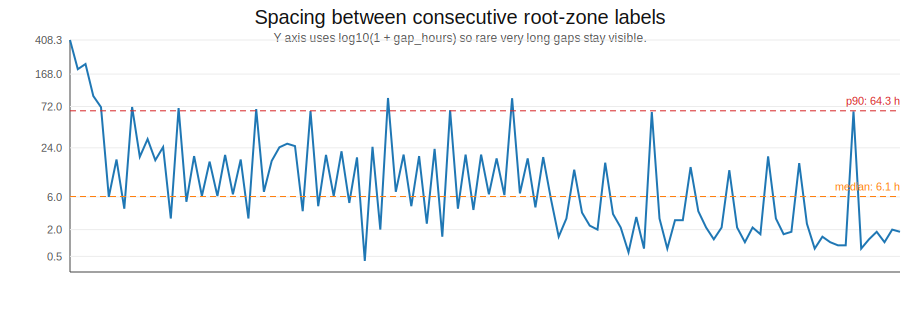

In [4]:
stats_df = pd.read_csv(EXPORT_DIR / "kalman_target_stats.csv", parse_dates=["holdout_start"])
display_df(stats_df)
master_df = load_master()
label_times = master_df.index[master_df["ph"].notna()]
gap_hours = pd.Series(label_times).diff().dt.total_seconds().div(3600).dropna().to_numpy()
display(SVG(svg_gap_timeline(gap_hours, title="Spacing between consecutive root-zone labels")))


## 2. Candidate Search

I tested multiple Kalman-style formulations rather than a single filter:

- `local_trend`: a two-state local level plus slope filter.
- `seasonal24h`: a diurnal harmonic state model for `pH`.
- `local_level_log`: a log-space local level model for `EC`.
- `delta_regression`: a Kalman update around a feature-driven delta forecast, using the same greenhouse/fertigation context already used by the project.

Selection is done using **pre-holdout CV only** so the notebook can answer the operational question fairly.


In [5]:
search_df = pd.read_csv(EXPORT_DIR / "kalman_model_search.csv")
search_df = search_df.sort_values(["target", "selected_by_cv", "holdout_mae"], ascending=[True, False, True])
display_df(search_df)


target,candidate,warmup_idx,holdout_start_idx,best_params,cv_mae,holdout_mae,holdout_rmse,holdout_r2,holdout_naive_mae,holdout_naive_rmse,holdout_naive_r2,selected_by_cv,best_holdout
ec,delta_regression,20,40,"{""alpha"": 100.0, ""q_scale"": 0.5, ""r_scale"": 0.25}",0.676,0.331,0.699,0.640,0.181,0.488,0.825,True,False
ec,local_trend,20,40,"{""q_scale"": 0.001, ""r_scale"": 10.0}",0.929,0.251,0.610,0.726,0.181,0.488,0.825,False,True
ec,local_level_log,20,40,"{""offset"": 0.2, ""q_scale"": 10.0, ""r_scale"": 10.0}",0.679,0.284,0.746,0.590,0.181,0.488,0.825,False,False
ph,seasonal24h,27,55,"{""q_level_scale"": 0.001, ""q_season_scale"": 0.0001, ""r_scale"": 0.01}",0.848,0.451,0.594,0.863,0.827,1.057,0.565,True,True
ph,local_trend,27,55,"{""q_scale"": 0.001, ""r_scale"": 10.0}",1.318,0.928,1.169,0.468,0.827,1.057,0.565,False,False
ph,delta_regression,27,55,"{""alpha"": 100.0, ""q_scale"": 0.01, ""r_scale"": 1.0}",0.881,1.275,1.995,-0.550,0.827,1.057,0.565,False,False


## 3. Side-by-Side Comparison with the Latest V7 Exports

The bar charts below compare the selected Kalman runs against the committed `v7_24h`, `v7_48h`, and naive carry-forward baselines.


target,model,selection_basis,rows,mae,rmse,r2
ec,v7_24h,committed_export,69,0.179,0.493,0.821
ec,v7_48h,committed_export,69,0.179,0.493,0.821
ec,naive_previous_value,committed_export,69,0.181,0.488,0.825
ec,kalman_best_holdout_local_trend,exploratory_holdout_best,69,0.251,0.610,0.726
ec,kalman_selected_delta_regression,best_pre_holdout_cv,69,0.331,0.699,0.640
ph,v7_24h,committed_export,54,0.332,0.429,0.928
ph,v7_48h,committed_export,54,0.340,0.450,0.921
ph,kalman_selected_seasonal24h,best_pre_holdout_cv,54,0.451,0.594,0.863
ph,kalman_best_holdout_seasonal24h,exploratory_holdout_best,54,0.451,0.594,0.863
ph,naive_previous_value,committed_export,54,0.827,1.057,0.565


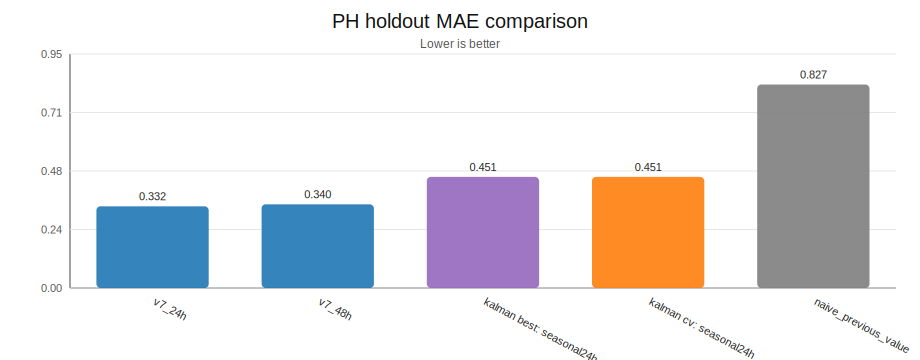

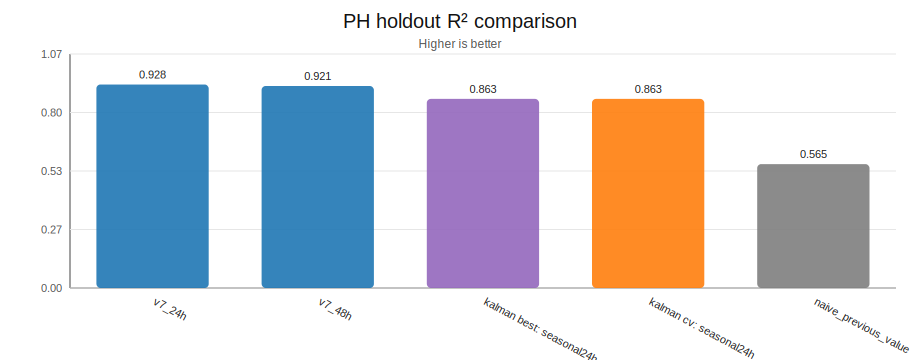

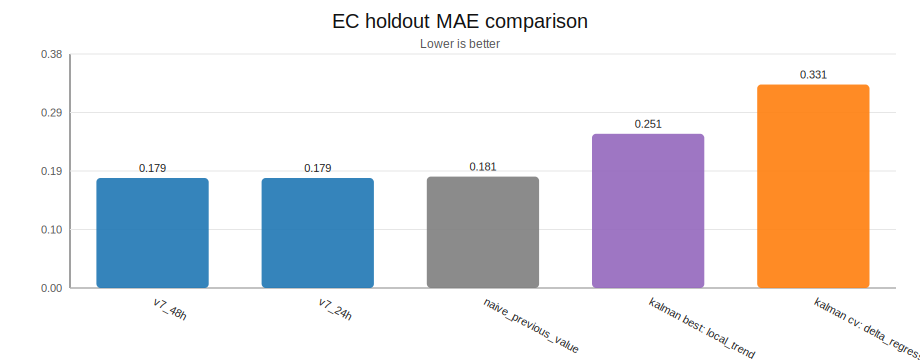

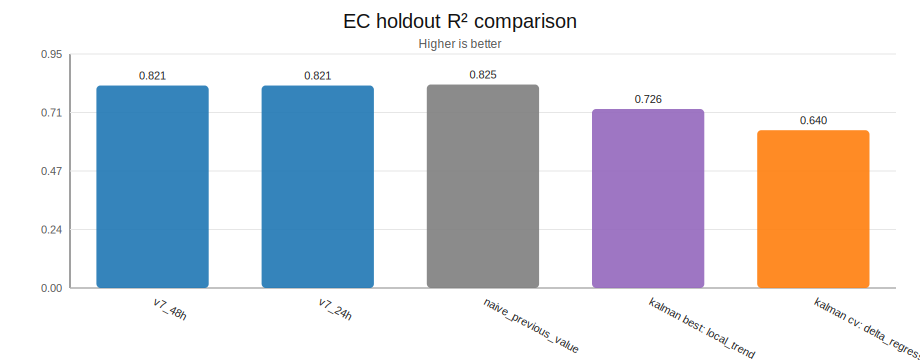

In [6]:
summary_df = pd.read_csv(EXPORT_DIR / "kalman_vs_v7_summary.csv")
display_df(summary_df.sort_values(["target", "mae"]))
for target in ("ph", "ec"):
    subset = summary_df[summary_df["target"] == target].copy().sort_values("mae")
    display(SVG(svg_metric_bar(subset, metric="mae", title=f"{target.upper()} holdout MAE comparison", lower_is_better=True)))
    display(SVG(svg_metric_bar(subset, metric="r2", title=f"{target.upper()} holdout R² comparison", lower_is_better=False)))


### Interpretation

- `pH` has enough recurring daily structure that a state-space model can track it reasonably well. The selected `seasonal24h` Kalman model beats naive carry-forward by a large margin, but it still trails `v7` by about **0.119 MAE**.
- `EC` is different. The CV-selected Kalman model is already weaker than `v7`, and it also underperforms the naive baseline in aggregate. That means the series is not behaving like a mostly smooth latent process with small measurement noise; it contains sharp operational shifts that the tested filters do not anticipate well enough.


## 4. Where the Kalman Models Fail

Aggregate metrics tell only part of the story. The error traces below show the operational failure modes directly.


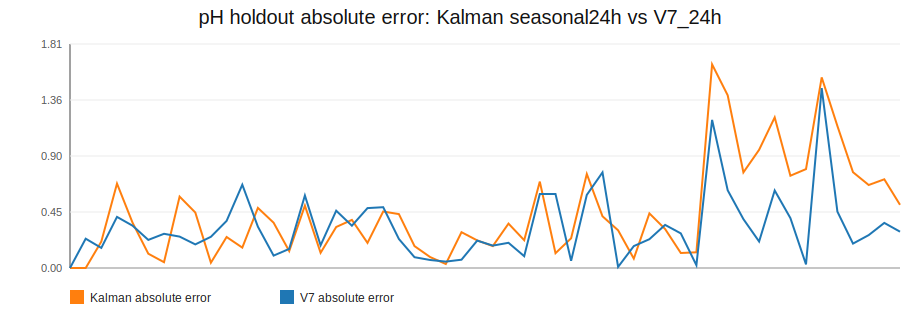

timestamp,true,kalman_pred,v7_pred,naive,kalman_abs_err,v7_abs_err
2025-09-18 09:40:00,6.970,8.613,8.165,7.760,1.643,1.195
2025-09-21 07:20:00,4.750,6.288,6.202,6.190,1.538,1.452
2025-09-18 10:30:00,6.710,8.103,7.337,6.970,1.393,0.627
2025-09-18 14:10:00,6.650,7.865,7.275,7.080,1.215,0.625
2025-09-21 08:40:00,4.750,5.896,4.295,4.750,1.146,0.455
2025-09-18 13:10:00,7.080,8.034,7.294,7.270,0.954,0.214
2025-09-21 06:30:00,6.190,5.392,6.161,6.800,0.798,0.029
2025-09-21 10:30:00,5.170,5.942,4.973,4.750,0.772,0.197
2025-09-18 12:00:00,7.270,8.041,6.876,6.710,0.771,0.394
2025-09-16 10:00:00,7.940,8.699,8.529,8.140,0.759,0.589


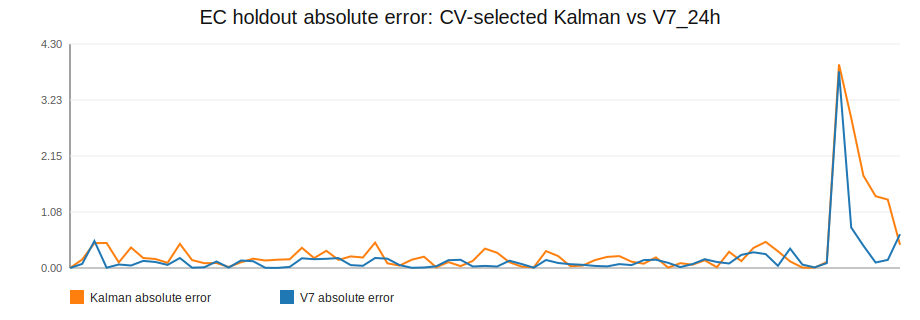

timestamp,true,kalman_pred,v7_pred,naive,kalman_abs_err,v7_abs_err
2025-09-21 07:20:00,4.230,0.316,0.451,0.501,3.914,3.779
2025-09-21 08:40:00,4.970,2.087,4.192,4.230,2.883,0.778
2025-09-21 10:30:00,4.520,2.745,4.949,4.970,1.775,0.429
2025-09-21 11:40:00,4.400,3.020,4.506,4.520,1.380,0.106
2025-09-21 13:40:00,4.530,3.216,4.374,4.400,1.314,0.156
2025-09-18 10:30:00,0.968,0.466,0.701,0.795,0.502,0.267
2025-09-09 18:40:00,0.161,0.650,0.353,0.347,0.489,0.192
2025-08-25 16:00:00,0.327,0.807,0.333,0.327,0.480,0.006
2025-08-25 09:00:00,0.327,0.806,0.845,0.828,0.479,0.518
2025-08-28 15:00:00,0.174,0.637,0.366,0.358,0.463,0.192


In [7]:
ph_kalman = pd.read_csv(EXPORT_DIR / "kalman_selected_eval_ph.csv", parse_dates=["timestamp"])
ph_v7 = pd.read_csv(EXPORT_DIR / "v7_24h_eval_ph.csv", parse_dates=["timestamp"]).rename(columns={"ph_true": "true", "ph_pred": "v7_pred", "ph_naive": "naive"})
ph_compare = ph_kalman[["timestamp", "true", "pred"]].rename(columns={"pred": "kalman_pred"})
ph_compare["v7_pred"] = ph_v7["v7_pred"]
ph_compare["kalman_abs_err"] = (ph_compare["true"] - ph_compare["kalman_pred"]).abs()
ph_compare["v7_abs_err"] = (ph_compare["true"] - ph_compare["v7_pred"]).abs()
display(SVG(svg_error_timeline(ph_compare, title="pH holdout absolute error: Kalman seasonal24h vs V7_24h")))
display_df(ph_compare.sort_values("kalman_abs_err", ascending=False).head(10))

ec_kalman = pd.read_csv(EXPORT_DIR / "kalman_selected_eval_ec.csv", parse_dates=["timestamp"])
ec_v7 = pd.read_csv(EXPORT_DIR / "v7_24h_eval_ec.csv", parse_dates=["timestamp"]).rename(columns={"ec_true": "true", "ec_pred": "v7_pred", "ec_naive": "naive"})
ec_compare = ec_kalman[["timestamp", "true", "pred"]].rename(columns={"pred": "kalman_pred"})
ec_compare["v7_pred"] = ec_v7["v7_pred"]
ec_compare["kalman_abs_err"] = (ec_compare["true"] - ec_compare["kalman_pred"]).abs()
ec_compare["v7_abs_err"] = (ec_compare["true"] - ec_compare["v7_pred"]).abs()
display(SVG(svg_error_timeline(ec_compare, title="EC holdout absolute error: CV-selected Kalman vs V7_24h")))
display_df(ec_compare.sort_values("kalman_abs_err", ascending=False).head(10))


## Final Assessment

### pH

Kalman filtering is **worth keeping as a benchmark** for `pH`. The best tested variant captures the daily oscillation well enough to materially improve over naive carry-forward, so it is a defensible low-complexity baseline or smoothing layer.

Still, the project should keep `v7` as the main predictor because it remains clearly better on the holdout: **MAE 0.332 vs 0.451**.

### EC

Kalman filtering is **not strong enough as a replacement model** for `EC` in the current setup. The main issue is abrupt regime change, especially around the late-September spike. The filters lag the jump rather than anticipating it, which is exactly where the feature-driven `v7` model is more appropriate.

### Recommendation

- Keep `v7` as the production-quality predictor for both targets.
- Use the Kalman notebook as a documented baseline and diagnostic tool.
- If you want a next Kalman step, the most sensible direction is **not** replacing `v7`, but using a Kalman smoother on top of `v7` predictions for `pH` only.
